# E04 – PyTorch alapok 1
**Generatív AI és inverz módszerek a képszintézisben** | BME, 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

## Tartalom
1. Tenzorok és autograd
2. Lineáris regresszió (kézzel és `nn.Linear`-ral)

In [ ]:
# Colab-on szükséges csomagok telepítése (lokálisan általában nem kell)
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install torch torchvision matplotlib numpy --quiet


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

# Eszköz kiválasztása: GPU ha elérhető, egyébként CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Használt eszköz: {device}')
print(f'PyTorch verzió: {torch.__version__}')


Használt eszköz: cuda
PyTorch verzió: 2.10.0+cu128


---
## 1. rész – Tenzorok és autograd
A PyTorch alapvető adatszerkezete a **tenzor** (`torch.Tensor`).
NumPy tömbökre hasonlít, de GPU-n is futhat, és automatikus differenciálást (autograd) is támogat.

### 1.1 Tenzor létrehozása, alakja, típusa

In [2]:
# Különböző módszerek tenzor létrehozására
a = torch.tensor([[1.0, 2.0, 3.0],
                   [4.0, 5.0, 6.0]])
print('Tenzor értéke:\n', a)
print('Alak (shape):  ', a.shape)   # torch.Size([2, 3])
print('Típus (dtype): ', a.dtype)   # torch.float32
print('Eszköz:        ', a.device)  # cpu

# Speciális tenzorok
nullak = torch.zeros(3, 4)
egyesek = torch.ones(2, 2)
veletlenszerű = torch.randn(3, 3)  # standard normális eloszlás
print('\nNullák (3x4):\n', nullak)
print('\nVéletlenszerű (3x3):\n', veletlenszerű)


Tenzor értéke:
 tensor([[1., 2., 3.],
        [4., 5., 6.]])
Alak (shape):   torch.Size([2, 3])
Típus (dtype):  torch.float32
Eszköz:         cpu

Nullák (3x4):
 tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

Véletlenszerű (3x3):
 tensor([[-1.0146, -0.0291,  0.8155],
        [ 1.5883, -0.9441, -1.3453],
        [ 0.8596, -0.1095, -2.2496]])


In [3]:
# Tenzor átalakítások: reshape, dtype-változtatás, GPU-ra küldés
x = torch.arange(12, dtype=torch.float32)  # [0, 1, ..., 11]
print('Eredeti:', x.shape)

x_2d = x.reshape(3, 4)
print('Átrendezve (3x4):\n', x_2d)

# Típus konverzió
x_int = x.to(torch.int64)
print('\nEgész típus:', x_int.dtype)

# GPU-ra másolás (ha elérhető)
x_gpu = x_2d.to(device)
print(f'\nEszközön: {x_gpu.device}')


Eredeti: torch.Size([12])
Átrendezve (3x4):
 tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

Egész típus: torch.int64

Eszközön: cuda:0


### 1.2 Aritmetika és broadcasting

In [4]:
# Elemenként végzett műveletek
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([10.0, 20.0, 30.0])

print('Összeadás:    ', a + b)
print('Szorzás:      ', a * b)
print('Hatványozás:  ', a ** 2)
print('Mátrixszorzás:', torch.dot(a, b))  # skaláris szorzat

# Mátrix szorzás
A = torch.randn(3, 4)
B = torch.randn(4, 5)
C = A @ B  # vagy: torch.mm(A, B)
print('\nMátrixszorzás alakja:', C.shape)  # (3, 5)


Összeadás:     tensor([11., 22., 33.])
Szorzás:       tensor([10., 40., 90.])
Hatványozás:   tensor([1., 4., 9.])
Mátrixszorzás: tensor(140.)

Mátrixszorzás alakja: torch.Size([3, 5])


In [5]:
# Broadcasting: különböző alakú tenzorok összeadása
# A kisebb tenzor automatikusan 'kiterjeszt'  – mint NumPy-ban
m = torch.ones(3, 4)        # shape: (3, 4)
v = torch.tensor([1., 2., 3., 4.])  # shape: (4,)

eredmeny = m + v  # v minden sorhoz hozzáadódik
print('Broadcasting eredmény (3x4):\n', eredmeny)

# Statisztikai függvények
x = torch.randn(100)
print(f'\nÁtlag: {x.mean():.4f}, Szórás: {x.std():.4f}')
print(f'Min:  {x.min():.4f}, Max: {x.max():.4f}')


Broadcasting eredmény (3x4):
 tensor([[2., 3., 4., 5.],
        [2., 3., 4., 5.],
        [2., 3., 4., 5.]])

Átlag: 0.0343, Szórás: 1.0317
Min:  -2.5148, Max: 2.6645


### 1.3 Autograd – automatikus differenciálás
A `requires_grad=True` beállítással a PyTorch nyomon követi a műveleteket,
és `.backward()` hívásával kiszámítja a gradienseket.

In [6]:
# Egyszerű autograd példa: f(x) = x^2 + 3x + 1, f'(x) = 2x + 3
x = torch.tensor(2.0, requires_grad=True)
f = x**2 + 3*x + 1

print(f'f(2) = {f.item():.1f}')  # 2^2 + 3*2 + 1 = 11

# Visszaterjesztés: kiszámítja a gradienseket
f.backward()

print(f'df/dx|x=2 = {x.grad.item():.1f}')  # 2*2 + 3 = 7


f(2) = 11.0
df/dx|x=2 = 7.0


In [7]:
# Több változós eset
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

# Előrevetítés (prediction): y_hat = w*x + b
x_adat = torch.tensor(3.0)
y_val  = torch.tensor(7.0)  # célérték: 2*3 + 1 = 7

y_hat = w * x_adat + b
loss  = (y_hat - y_val) ** 2  # négyzetes hiba

loss.backward()
print(f'loss = {loss.item():.4f}')
print(f'dL/dw = {w.grad.item():.4f}')
print(f'dL/db = {b.grad.item():.4f}')


loss = 16.0000
dL/dw = -24.0000
dL/db = -8.0000


In [8]:
# torch.no_grad(): kikapcsoljuk a gradiens-számítást (pl. kiértékeléskor)
x = torch.tensor(5.0, requires_grad=True)

with torch.no_grad():
    y = x * 2 + 1
    print('requires_grad kikapcsolva:', y.requires_grad)  # False

# A modell paramétereinek frissítésekor szükséges:
# w.data -= lr * w.grad  (a .data eléréssel elkerüljük a gradiens-gráf bővítését)
print('\nPélda: paraméter kézi frissítése')
w = torch.tensor(1.5, requires_grad=True)
grads_w = torch.tensor(0.4)  # tegyük fel, ezt kaptuk backward()-tól
with torch.no_grad():
    w -= 0.1 * grads_w        # tanulási ráta: 0.1
print(f'Frissített w: {w.item():.4f}')


requires_grad kikapcsolva: False

Példa: paraméter kézi frissítése
Frissített w: 1.4600


---
## 2. rész – Lineáris regresszió
**Feladat:** illesztsük az `y = 2x + 1` egyenest szintetikus, zajos adatokra.

Először **kézileg** (csak autograd, nn nélkül), majd **`nn.Linear`** és **`SGD`** optimizer segítségével.

### 2.1 Szintetikus adatok generálása

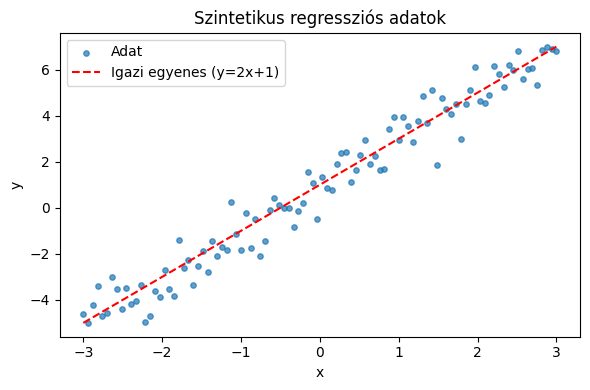

In [9]:
torch.manual_seed(42)
np.random.seed(42)

# Igazi paraméterek: w=2, b=1
N = 100
x_np = np.linspace(-3, 3, N).astype(np.float32)
y_np = 2.0 * x_np + 1.0 + np.random.randn(N).astype(np.float32) * 0.8

x_tensor = torch.from_numpy(x_np).unsqueeze(1)  # (N, 1)
y_tensor = torch.from_numpy(y_np).unsqueeze(1)  # (N, 1)

plt.figure(figsize=(6, 4))
plt.scatter(x_np, y_np, s=15, alpha=0.7, label='Adat')
plt.plot(x_np, 2*x_np + 1, 'r--', label='Igazi egyenes (y=2x+1)')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Szintetikus regressziós adatok')
plt.legend(); plt.tight_layout(); plt.show()


### 2.2 Kézi gradiens-ereszkedés (nn nélkül)
Közvetlenül `w` és `b` tenzorokat tanítunk, az autograd segítségével.

In [ ]:
# Paraméterek inicializálása (véletlenszerűen)
torch.manual_seed(0)
w = torch.randn(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

lr = 0.05
n_epochok = 200
veszteségek = []

for epoch in range(n_epochok):
    # Előrevetítés
    y_hat = x_tensor * w + b          # broadcasting: (N,1) * (1,) -> (N,1)

    # MSE veszteség
    loss = ((y_hat - y_tensor) ** 2).mean()
    veszteségek.append(loss.item())

    # Gradiensek törlése (az előző iterációból maradtak)
    if w.grad is not None:
        w.grad.zero_()
    if b.grad is not None:
        b.grad.zero_()

    # Visszaterjesztés: kiszámolja dL/dw és dL/db értékeket
    loss.backward()

    # Paraméter frissítése (gradiens-ereszkedés lépés)
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

print(f'Tanult w = {w.item():.4f}  (igazi: 2.0)')
print(f'Tanult b = {b.item():.4f}  (igazi: 1.0)')

plt.figure(figsize=(6, 3))
plt.plot(veszteségek)
plt.xlabel('Epoch'); plt.ylabel('MSE veszteség')
plt.title('Veszteség alakulása (kézi GD)')
plt.tight_layout(); plt.show()


### 2.3 Lineáris regresszió `nn.Linear` és `SGD` optimizer segítségével
Az `nn` modul és az optimizerek sok technikai részletet elfednek – ez a 'PyTorch-os' megközelítés.

In [ ]:
# Modell, veszteségfüggvény, optimizer
torch.manual_seed(0)
model  = nn.Linear(in_features=1, out_features=1)  # w, b automatikusan inicializálva
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.05)

veszteségek2 = []
n_epochok = 200

for epoch in range(n_epochok):
    model.train()

    # 1. Gradiensek nullázása
    optimizer.zero_grad()

    # 2. Előrevetítés
    y_hat = model(x_tensor)

    # 3. Veszteség
    loss = criterion(y_hat, y_tensor)
    veszteségek2.append(loss.item())

    # 4. Visszaterjesztés
    loss.backward()

    # 5. Paraméter frissítés
    optimizer.step()

w_tanult = model.weight.item()
b_tanult = model.bias.item()
print(f'Tanult w = {w_tanult:.4f}  (igazi: 2.0)')
print(f'Tanult b = {b_tanult:.4f}  (igazi: 1.0)')


In [ ]:
# Eredmény megjelenítése
model.eval()
with torch.no_grad():
    x_plot = torch.linspace(-3, 3, 100).unsqueeze(1)
    y_pred = model(x_plot).numpy()

plt.figure(figsize=(6, 4))
plt.scatter(x_np, y_np, s=15, alpha=0.6, label='Adatok')
plt.plot(x_np, 2*x_np + 1, 'r--', label='Igazi egyenes')
plt.plot(x_plot.numpy(), y_pred, 'g-', linewidth=2, label=f'Illesztett: {w_tanult:.2f}x + {b_tanult:.2f}')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Lineáris regresszió – illesztett egyenes')
plt.legend(); plt.tight_layout(); plt.show()
